In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
netflix_data = pd.read_csv('/kaggle/input/netflix-titles/netflix_titles.csv')

In [3]:
netflix_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
netflix_shows = netflix_data[netflix_data['type'] == 'TV Show']
netflix_movies = netflix_data[netflix_data['type'] == 'Movie']

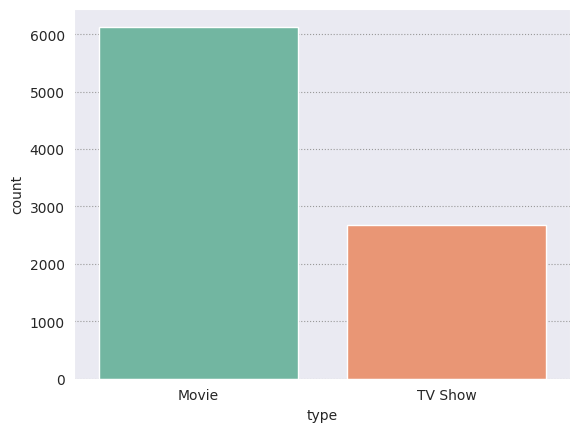

In [6]:
sns.set_style("darkgrid",{"grid.color":".6","grid.linestyle" : ":"})
ax = sns.countplot(x = "type",data=netflix_data,palette = "Set2" )

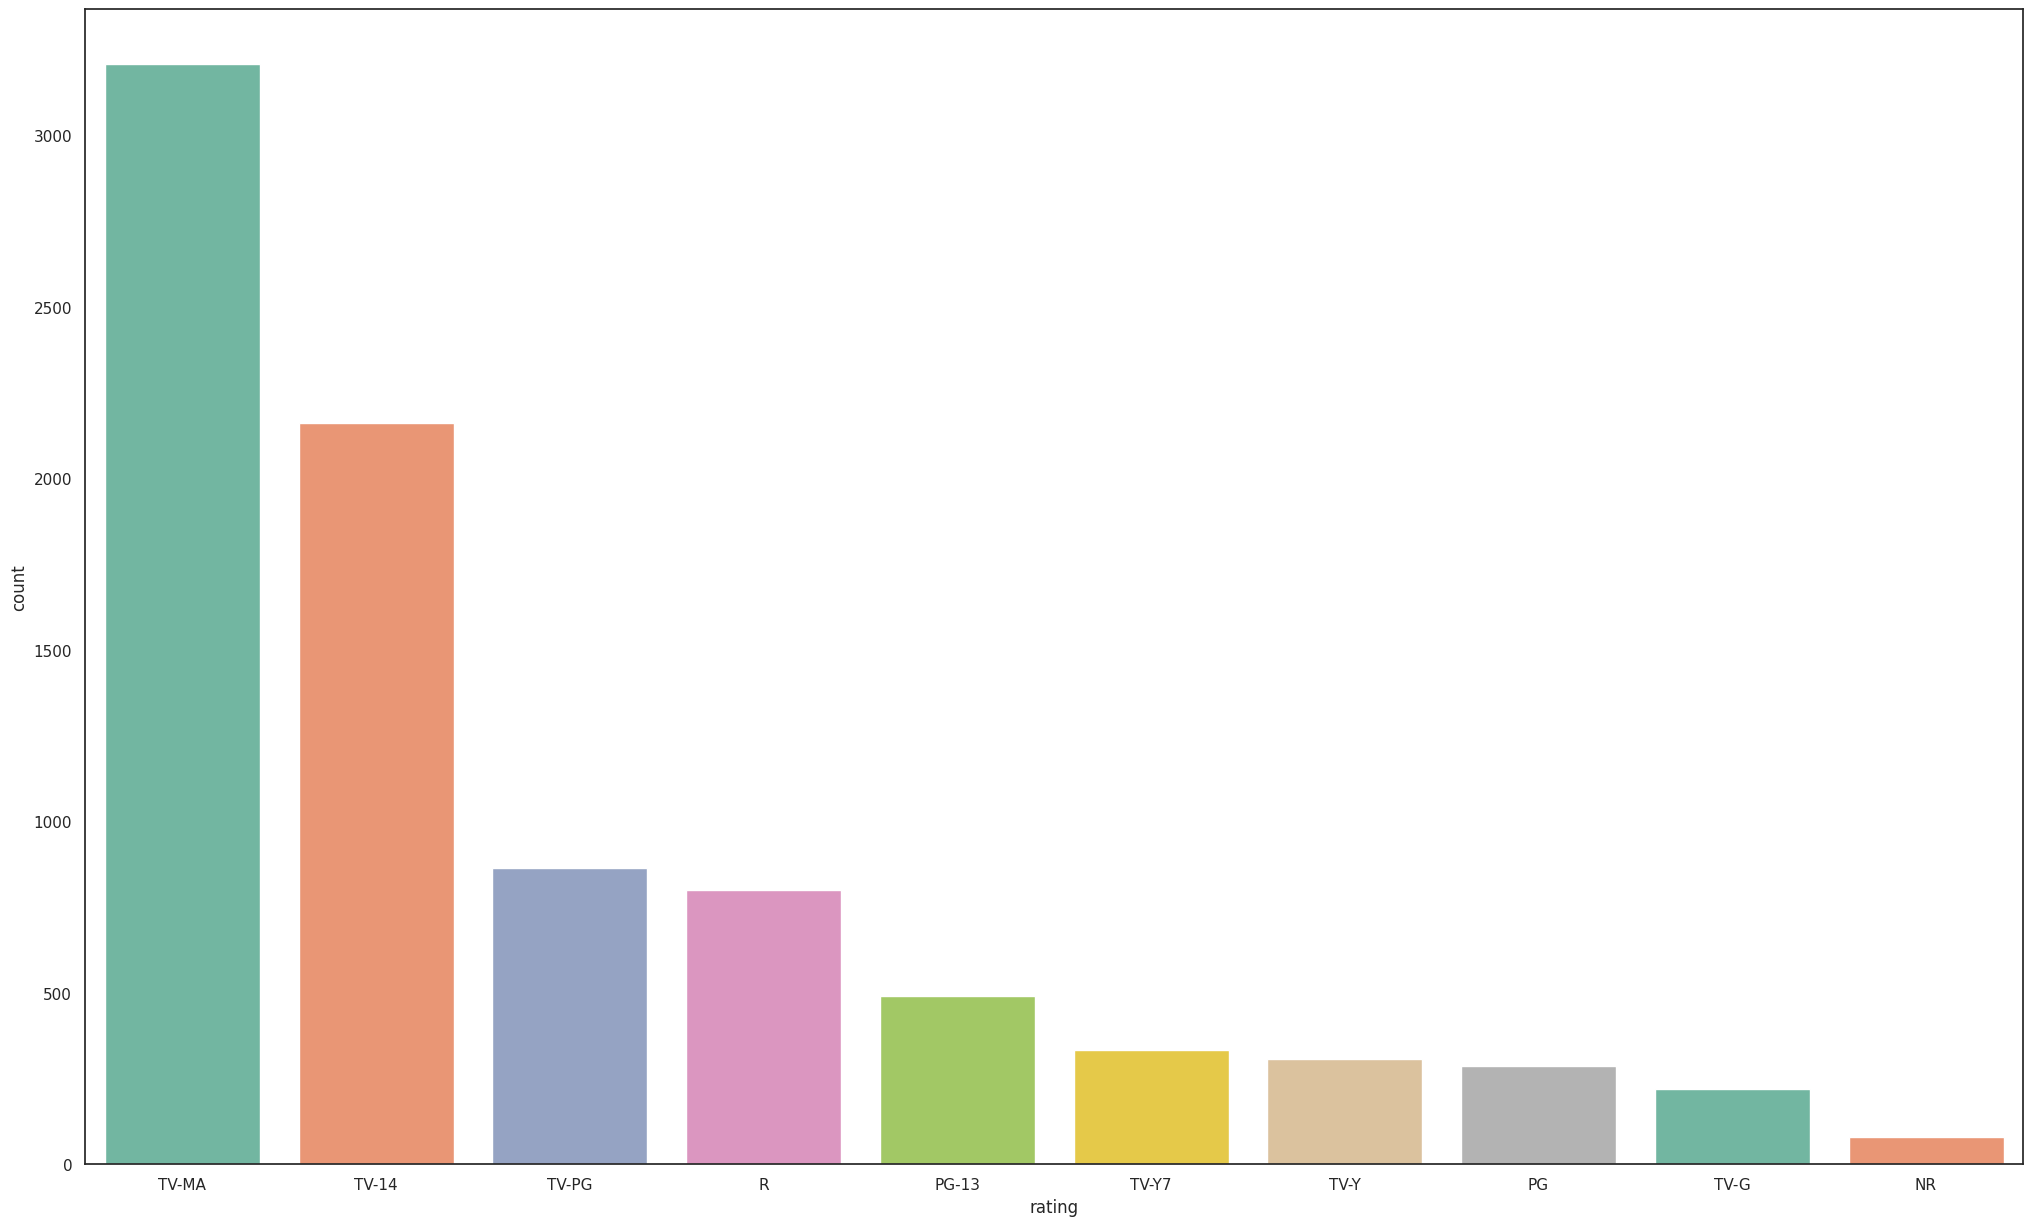

In [7]:
plt.figure(figsize = (25, 15))
sns.set(style='white')
ax = sns.countplot(x='rating',data = netflix_data,palette = 'Set2', order = netflix_data['rating'].value_counts().index[0:10])

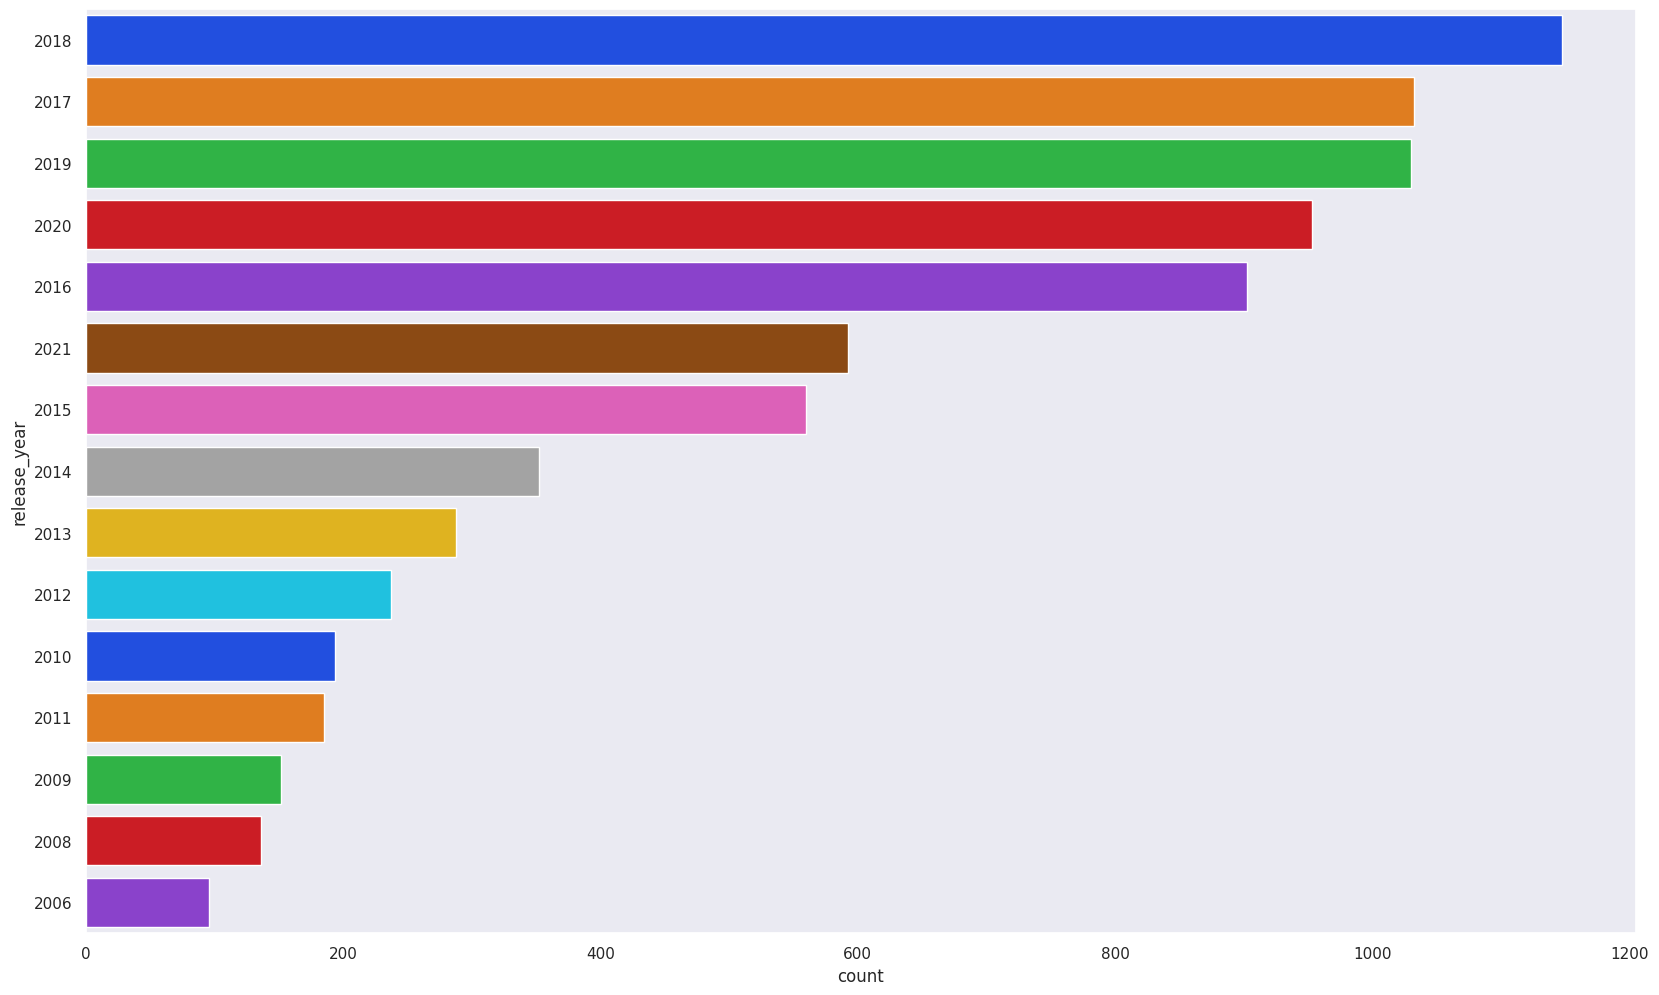

In [8]:
plt.figure(figsize = (20,12))
sns.set(style = "dark")
ax = sns.countplot(y = "release_year",data = netflix_data,palette = 'bright',order = netflix_data['release_year'].value_counts().index[0:15] )

In [9]:
from sklearn.feature_extraction.text  import TfidfVectorizer

In [10]:
tfidf = TfidfVectorizer(stop_words = 'english')
netflix_data['description'] = netflix_data['description'].fillna('')
tfidf_matrix = tfidf.fit_transform(netflix_data['description'])
tfidf_matrix.shape

(8807, 18895)

In [11]:
from sklearn.metrics.pairwise import linear_kernel 
cosine_sim = linear_kernel(tfidf_matrix,tfidf_matrix)

In [12]:
indices = pd.Series(netflix_data.index, index = netflix_data['title']).drop_duplicates()

In [13]:
def get_recommendations(title,cosine_sim = cosine_sim):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores,key=lambda x : x[1],reverse = True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]

    return netflix_data['title'].iloc[movie_indices]

In [14]:
get_recommendations('Peaky Blinders')

7683                    Our Godfather
2646                   My Stupid Boss
3133                              Don
8293                         The Fear
7140    Jonathan Strange & Mr Norrell
7785                Power Rangers Zeo
8467                       The Prison
8539                       The Tudors
1510                    The Con Is On
8391     The Legend of Michael Mishra
Name: title, dtype: object

In [15]:
get_recommendations('Dark')

2874                   Altered Carbon
4629                           Maniac
1034                       Synchronic
626     Sophie: A Murder in West Cork
1117         Ibrahim a Fate to Define
4101                        Candyflip
4253       Black Mirror: Bandersnatch
869                  Who Killed Sara?
2979                     THE STRANGER
7348                        Love Rain
Name: title, dtype: object

In [16]:
get_recommendations('Altered Carbon')

1045               Next in Fashion
1034                    Synchronic
2327                          Dark
3772                 Alles ist gut
4629                        Maniac
8785                           YOM
4101                     Candyflip
4566           Freedom at Midnight
4253    Black Mirror: Bandersnatch
5109                Part-Time Idol
Name: title, dtype: object

In [17]:
missingfilled = netflix_data.fillna('')
missingfilled.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,,,,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [18]:
def data_cleaning(x):
    return str.lower(x.replace(' ',""))

In [19]:
features = ['title','director','cast','listed_in','description']
missingfilled = missingfilled[features]
missingfilled.head()

,title,director,cast,listed_in,description
0,Dick Johnson Is Dead,Kirsten Johnson,,Documentaries,"As her father nears the end of his life, filmm..."
1,Blood & Water,,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...","International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...","Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,Jailbirds New Orleans,,,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,Kota Factory,,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...","International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [20]:
for feature in features:
    missingfilled[feature] = missingfilled[feature].apply(data_cleaning)

missingfilled.head(2)

,title,director,cast,listed_in,description
0,dickjohnsonisdead,kirstenjohnson,,documentaries,"asherfathernearstheendofhislife,filmmakerkirst..."
1,blood&water,,"amaqamata,khosingema,gailmabalane,thabangmolab...","internationaltvshows,tvdramas,tvmysteries","aftercrossingpathsataparty,acapetownteensetsou..."


In [21]:
def content_include(x):
    return x['title']+ ' ' + x['cast']+ ' ' + x['listed_in']+ ' ' + x['description']

In [22]:
missingfilled['soup'] = missingfilled.apply(content_include,axis = 1)

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [24]:
countvec = CountVectorizer(stop_words = 'english')
countvec_matrix = countvec.fit_transform(missingfilled['soup'])

cosine_sim2 = cosine_similarity(countvec_matrix,countvec_matrix)

In [25]:
missingfilled = missingfilled.reset_index()
indices = pd.Series(missingfilled.index, index = missingfilled['title'])

In [26]:
def get_recommendations_new(title,cosine_sim = cosine_sim):
    title=title.replace(' ','').lower()
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores,key=lambda x : x[1],reverse = True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]

    return netflix_data['title'].iloc[movie_indices]

In [27]:
get_recommendations_new('The Defeated',cosine_sim2)

4129                 Safe
4410            Damnation
2327                 Dark
3604             Sintonia
2053      Young Wallander
3589         Sacred Games
3744              Unit 42
5404    The Truth Seekers
6323          Black Heart
3789       Killer Ratings
Name: title, dtype: object